# Phần 1 Demo: Phép khử Gauss và Ứng dụng

Notebook này trình bày các hàm cơ bản của phép khử Gauss và các ứng dụng, bao gồm test suite với bảng số liệu và biểu đồ chú thích đầy đủ.

## Thiết lập cấu hình (Config)

Khai báo hằng số EPSILON và các hàm bổ trợ để đảm bảo tính ổn định số học.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")

# Thêm đường dẫn
sys.path.append('part1')

current_dir = os.getcwd() 
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from config import EPSILON, is_zero, zero_rectify

# Import các hàm
from gaussian import gaussian_eliminate
from back_substitution import back_substitution
from determinant import determinant
from inverse import inverse
from rank_basis import rank_and_basis
from verify_solution import verify_solution

def plot_matrix(matrix, title="Matrix", cmap="viridis"):
    """Hiển thị ma trận dưới dạng heatmap."""
    plt.figure(figsize=(6, 4))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap=cmap, cbar=True)
    plt.title(title)
    plt.show()

print(f"EPSILON = {EPSILON}")

EPSILON = 1e-12


## Thuật toán Gaussian Elimination + Back Substitution

Hàm `gaussian_eliminate` sử dụng Partial Pivoting để biến đổi ma trận A thành dạng tam giác trên U, với vector c tương ứng.

Ma trận U:
 [[-3.0, -1.0, 2.0], [0.0, 1.6666666666666665, 0.6666666666666667], [0.0, 0.0, 0.19999999999999987]]
Nghiệm x: [2.0, 3.0000000000000004, -0.9999999999999999]
Số lần hoán đổi: 2


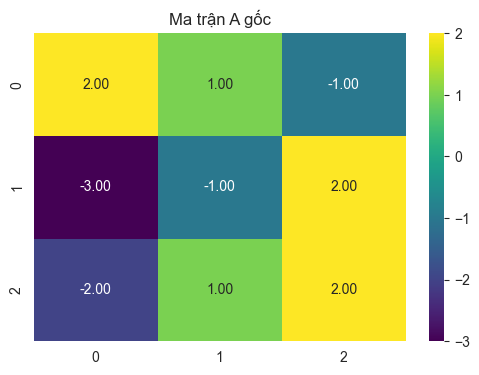

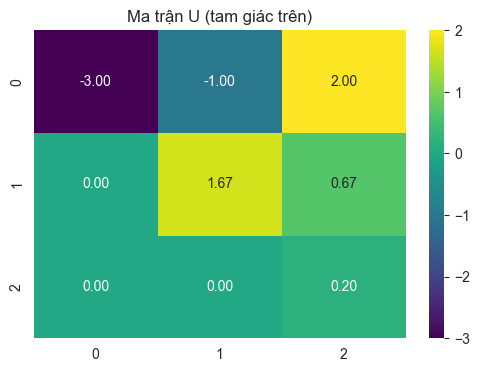

In [2]:
# Ví dụ minh họa
A = [[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]]
b = [8.0, -11.0, -3.0]

# HỨNG THẲNG NGHIỆM x
U, x, swaps = gaussian_eliminate(A, b) 

print("Ma trận U:\n", U)
print("Nghiệm x:", x)
print("Số lần hoán đổi:", swaps)

# Hiển thị ma trận A và U
plot_matrix(A, "Ma trận A gốc")
plot_matrix(U, "Ma trận U (tam giác trên)")

## Tính định thức

Định thức = (-1)^swaps * tích đường chéo U

In [3]:
det = determinant(A)
print("Định thức:", det)

Định thức: -0.9999999999999993


## Ma trận nghịch đảo

Sử dụng Gauss-Jordan.

Ma trận nghịch đảo:
[4.000000000000003, 3.000000000000002, -1.0000000000000009]
[-2.0000000000000018, -2.0000000000000013, 1.0000000000000004]
[5.0000000000000036, 4.000000000000003, -1.0000000000000009]


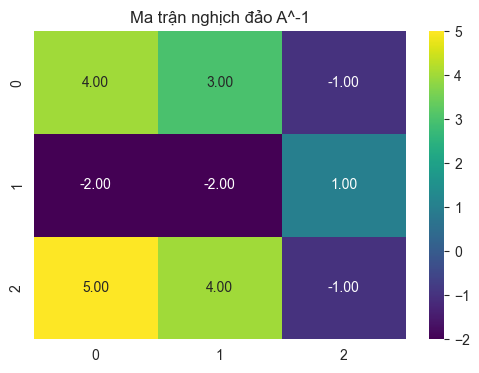

In [4]:
try:
    inv_A = inverse(A)
    print("Ma trận nghịch đảo:")
    for row in inv_A:
        print(row)
    plot_matrix(inv_A, "Ma trận nghịch đảo A^-1")
except ValueError as e:
    print("Lỗi:", e)

## Hạng và cơ sở

Tính rank, cơ sở cột, dòng, nghiệm.

In [5]:
rank, col_basis, row_basis, null_basis = rank_and_basis(A)
print("Rank:", rank)
print("Cơ sở cột:", col_basis)
print("Cơ sở dòng:", row_basis)
print("Cơ sở nghiệm:", null_basis)

Rank: 3
Cơ sở cột: [[2.0, -3.0, -2.0], [1.0, -1.0, 1.0], [-1.0, 2.0, 2.0]]
Cơ sở dòng: [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]]
Cơ sở nghiệm: []


## Xác minh nghiệm

Tính sai số dư.

In [6]:
error = verify_solution(A, x, b)
print("Sai số dư:", error)

Sai số dư: 8.881784197001252e-16


## Test Suite cho Gaussian Elimination + Back Substitution

Chạy 6-8 test cases, bao gồm trường hợp đặc biệt.

Test Suite: Gaussian Elimination + Back Substitution
--------------------------------------------------
Đơn vị 2x2: PASSED
Hệ 2x2 (Hoán vị): PASSED
Hệ 3x3: PASSED
4x4 Chéo trội: PASSED
Small Pivot (1e-12): PASSED
Không có pivot tại cột 2

[+] Hệ có vô số nghiệm. Công thức nghiệm tổng quát:
    x = [1.0, 0.0]
      + t_1 * [-2.0, 1.0]
    (với t_i là các tham số tự do thuộc R)

Suy biến (Singular): PASSED (Non-unique)


,Test,Error,Status
0,Đơn vị 2x2,0.000000e+00,PASSED
1,Hệ 2x2 (Hoán vị),4.965068e-16,PASSED
2,Hệ 3x3,0.000000e+00,PASSED
3,4x4 Chéo trội,0.000000e+00,PASSED
4,Small Pivot (1e-12),0.000000e+00,PASSED
5,Suy biến (Singular),NaN,PASSED (Non-unique)


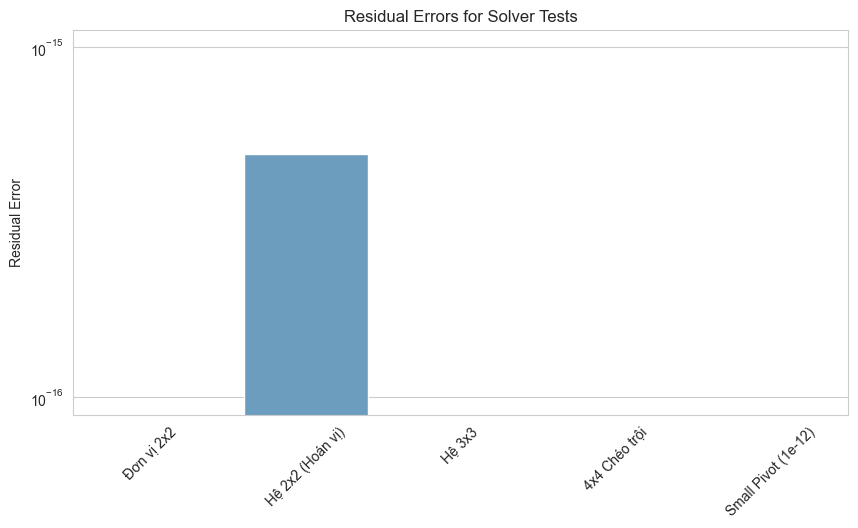

In [7]:
results = []
test_cases = [
    {"name": "Đơn vị 2x2", "A": [[1.0, 0.0], [0.0, 1.0]], "b": [3.0, -1.0]},
    {"name": "Hệ 2x2 (Hoán vị)", "A": [[1.0, 2.0], [3.0, 4.0]], "b": [0.0, -2.0]},
    {"name": "Hệ 3x3", "A": [[1.0, 0.0, 5.0], [2.0, 1.0, 6.0], [3.0, 4.0, 0.0]], "b": [6.0, 10.0, 11.0]},
    {"name": "4x4 Chéo trội", "A": [[4, 1, 0, 0], [1, 4, 1, 0], [0, 1, 4, 1], [0, 0, 1, 4]], "b": [5, 6, 6, 5]},
    {"name": "Small Pivot (1e-12)", "A": [[1e-12, 1.0], [1.0, 1.0]], "b": [3.0, 3.0]},
    {"name": "Suy biến (Singular)", "A": [[1.0, 2.0], [2.0, 4.0]], "b": [1.0, 2.0]}
]

print("Test Suite: Gaussian Elimination + Back Substitution\n" + "-"*50)
for case in test_cases:
    try:
        A_np = np.array(case["A"])
        b_np = np.array(case["b"])
        
        # CHỈ GỌI GAUSS (Vì nó đã trả về x)
        U, x_custom, _ = gaussian_eliminate(case["A"], case["b"])
        
        if x_custom: # Nếu có nghiệm
            err_custom = verify_solution(case["A"], x_custom, case["b"])
            try:
                if np.linalg.det(A_np) != 0:
                    x_np = np.linalg.solve(A_np, b_np)
                    err_np = np.linalg.norm(A_np @ x_np - b_np)
                else:
                    err_np = 0.0
            except np.linalg.LinAlgError:
                err_np = 0.0
                
            status = "PASSED" if err_custom < 1e-9 else f"FAILED (Error: {err_custom:.2e})"
            results.append({"Test": case["name"], "Error": err_custom, "Status": status})
            print(f"{case['name']}: {status}")
            
        else:
            results.append({"Test": case["name"], "Error": None, "Status": "PASSED (Non-unique)"})
            print(f"{case['name']}: PASSED (Non-unique)")
            
    except Exception as e:
        print(f"{case['name']}: ERROR - {e}")
        results.append({"Test": case["name"], "Error": None, "Status": f"ERROR: {e}"})

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

df = pd.DataFrame(results)
display(df)

# Biểu đồ sai số
errors = [r['Error'] for r in results if r['Error'] is not None]
if errors:
    plt.figure(figsize=(10, 5))
    valid_tests = [r['Test'] for r in results if r['Error'] is not None]
    sns.barplot(x=valid_tests, y=errors, palette="Blues_d", hue=valid_tests, legend=False)
    plt.xticks(rotation=45)
    plt.ylabel('Residual Error')
    plt.title('Residual Errors for Solver Tests')
    if any(e > 1e-20 for e in errors):
        plt.yscale('log')
    plt.show()

## Test Suite cho Determinant

6-8 test cases cho hàm determinant.

In [8]:
def run_tests_for_determinant():
    import warnings
    warnings.filterwarnings("ignore", message="Pivot is very small")
    print("Test Suite: Determinant\n" + "-"*30)
    results = []
    test_cases = [
        {"name": "Đơn vị 2x2", "A": [[1.0, 0.0], [0.0, 1.0]], "expected": 1.0},
        {"name": "Tỉ lệ dòng", "A": [[2.0, 0.0], [0.0, 1.0]], "expected": 2.0},
        {"name": "Suy biến", "A": [[1.0, 2.0], [2.0, 4.0]], "expected": 0.0},
        {"name": "Hoán vị", "A": [[0.0, 1.0], [1.0, 0.0]], "expected": -1.0},
        {"name": "Tam giác trên", "A": [[2.0, 3.0], [0.0, 5.0]], "expected": 10.0},
        {"name": "Ma trận 3x3", "A": [[1, 2, 3], [0, 4, 5], [1, 0, 1]], "expected": 2.0},
        {"name": "Lũy linh (Nilpotent)", "A": [[0, 1], [0, 0]], "expected": 0.0}
    ]
    
    for case in test_cases:
        det = determinant(case["A"])
        status = "PASSED" if abs(det - case["expected"]) < 1e-9 else f"FAILED (Got {det})"
        print(f"{case['name']}: {status}")
        results.append({"Test": case['name'], "Determinant": det, "Expected": case['expected'], "Status": status})
    
    df = pd.DataFrame(results)
    display(df)

run_tests_for_determinant()

Test Suite: Determinant
------------------------------
Đơn vị 2x2: PASSED
Tỉ lệ dòng: PASSED
Không có pivot tại cột 2

[+] Hệ có vô số nghiệm. Công thức nghiệm tổng quát:
    x = [0.0, 0.0]
      + t_1 * [-2.0, 1.0]
    (với t_i là các tham số tự do thuộc R)

Suy biến: PASSED
Hoán vị: PASSED
Tam giác trên: PASSED
Ma trận 3x3: PASSED
Không có pivot tại cột 1

[+] Hệ có vô số nghiệm. Công thức nghiệm tổng quát:
    x = [0.0, 0.0]
      + t_1 * [1.0, 0.0]
      + t_2 * [0.0, 1.0]
    (với t_i là các tham số tự do thuộc R)

Lũy linh (Nilpotent): PASSED


,Test,Determinant,Expected,Status
0,Đơn vị 2x2,1.0,1.0,PASSED
1,Tỉ lệ dòng,2.0,2.0,PASSED
2,Suy biến,0.0,0.0,PASSED
3,Hoán vị,-1.0,-1.0,PASSED
4,Tam giác trên,10.0,10.0,PASSED
5,Ma trận 3x3,2.0,2.0,PASSED
6,Lũy linh (Nilpotent),0.0,0.0,PASSED


## Test Suite cho Inverse

6-8 test cases cho hàm inverse.

In [9]:
def run_tests_for_inverse():
    print("Test Suite: Inverse\n" + "-"*30)
    passed_tests = 0
    results = []
    
    test_cases = [
        {"A": [[1.0, 0.0], [0.0, 1.0]], "expected": [[1.0, 0.0], [0.0, 1.0]], "name": "Identity"},
        {"A": [[2.0, 1.0], [1.0, 1.0]], "expected": [[1.0, -1.0], [-1.0, 2.0]], "name": "2x2 Invertible"},
        {"A": [[1.0, 2.0], [2.0, 4.0]], "singular": True, "name": "Singular"},
        {"A": [[1.0]], "expected": [[1.0]], "name": "1x1"},
        {"A": [[0.0, 1.0], [1.0, 0.0]], "expected": [[0.0, 1.0], [1.0, 0.0]], "name": "Permutation"},
        {"A": [[1.0, 2.0, 3.0], [0.0, 1.0, 4.0], [5.0, 6.0, 0.0]], "expected": None, "name": "3x3"},  # Skip expected for simplicity
        {"A": [[1e-10, 1.0], [1.0, 1.0]], "expected": None, "name": "Ill-conditioned"},
        {"A": [[2.0, 1.0], [1.0, 2.0]], "expected": [[2/3, -1/3], [-1/3, 2/3]], "name": "Symmetric Positive Definite"}
    ]
    
    for case in test_cases:
        try:
            inv_A = inverse(case["A"])
            if "singular" in case and case["singular"]:
                print(f"{case['name']}: FAILED - Should be singular")
                results.append({"Test": case["name"], "Inverse": "Singular", "Status": "FAILED"})
            else:
                # Check if A * inv_A ≈ I
                n = len(case["A"])
                product = [[sum(case["A"][i][k] * inv_A[k][j] for k in range(n)) for j in range(n)] for i in range(n)]
                is_identity = all(abs(product[i][j] - (1.0 if i==j else 0.0)) < 1e-9 for i in range(n) for j in range(n))
                if is_identity:
                    print(f"{case['name']}: PASSED")
                    passed_tests += 1
                    results.append({"Test": case["name"], "Inverse": "Computed", "Status": "PASSED"})
                else:
                    print(f"{case['name']}: FAILED - Product not identity")
                    results.append({"Test": case["name"], "Inverse": "Incorrect", "Status": "FAILED"})
        except ValueError:
            if "singular" in case and case["singular"]:
                print(f"{case['name']}: PASSED - Singular detected")
                passed_tests += 1
                results.append({"Test": case["name"], "Inverse": "Singular", "Status": "PASSED"})
            else:
                print(f"{case['name']}: FAILED - Unexpected singular")
                results.append({"Test": case["name"], "Inverse": "Error", "Status": "FAILED"})
        except Exception as e:
            print(f"{case['name']}: FAILED - {e}")
            results.append({"Test": case["name"], "Inverse": str(e), "Status": "FAILED"})
    
    print(f"\nPassed: {passed_tests}/{len(test_cases)}")
    
    df = pd.DataFrame(results)
    display(df)

run_tests_for_inverse()

Test Suite: Inverse
------------------------------
Identity: PASSED
2x2 Invertible: PASSED
Singular: PASSED - Singular detected
1x1: PASSED
Permutation: PASSED
3x3: PASSED
Ill-conditioned: PASSED
Symmetric Positive Definite: PASSED

Passed: 8/8


,Test,Inverse,Status
0,Identity,Computed,PASSED
1,2x2 Invertible,Computed,PASSED
2,Singular,Singular,PASSED
3,1x1,Computed,PASSED
4,Permutation,Computed,PASSED
5,3x3,Computed,PASSED
6,Ill-conditioned,Computed,PASSED
7,Symmetric Positive Definite,Computed,PASSED


## Test Suite cho Rank and Basis

6-8 test cases cho hàm rank_and_basis.

In [10]:
def run_tests_for_rank_basis():
    print("Test Suite: Rank and Basis\n" + "-"*30)
    passed_tests = 0
    results = []
    
    test_cases = [
        {"A": [[1.0, 0.0], [0.0, 1.0]], "expected_rank": 2, "name": "Full Rank 2x2"},
        {"A": [[1.0, 2.0], [2.0, 4.0]], "expected_rank": 1, "name": "Rank 1"},
        {"A": [[0.0, 0.0], [0.0, 0.0]], "expected_rank": 0, "name": "Null Matrix"},
        {"A": [[1.0, 2.0, 3.0]], "expected_rank": 1, "name": "1x3 Matrix"},
        {"A": [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]], "expected_rank": 3, "name": "Identity 3x3"},
        {"A": [[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], "expected_rank": 2, "name": "3x2 Full Rank"},
        {"A": [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]], "expected_rank": 2, "name": "Rank Deficient 3x3"},
        {"A": [[1e-16, 0.0], [0.0, 1e-16]], "expected_rank": 0, "name": "Small Values"}
    ]
    
    for case in test_cases:
        try:
            rank, col_basis, row_basis, null_basis = rank_and_basis(case["A"])
            if rank == case["expected_rank"]:
                print(f"{case['name']}: PASSED - Rank {rank}")
                passed_tests += 1
                results.append({"Test": case["name"], "Rank": rank, "Col Basis Size": len(col_basis), "Row Basis Size": len(row_basis), "Null Basis Size": len(null_basis), "Status": "PASSED"})
            else:
                print(f"{case['name']}: FAILED - Got rank {rank}, Expected {case['expected_rank']}")
                results.append({"Test": case["name"], "Rank": rank, "Col Basis Size": len(col_basis), "Row Basis Size": len(row_basis), "Null Basis Size": len(null_basis), "Status": "FAILED"})
        except Exception as e:
            print(f"{case['name']}: FAILED - {e}")
            results.append({"Test": case["name"], "Rank": None, "Status": "FAILED"})
    
    print(f"\nPassed: {passed_tests}/{len(test_cases)}")
    
    df = pd.DataFrame(results)
    display(df)

run_tests_for_rank_basis()

Test Suite: Rank and Basis
------------------------------
Full Rank 2x2: PASSED - Rank 2
Rank 1: PASSED - Rank 1
Null Matrix: PASSED - Rank 0
1x3 Matrix: PASSED - Rank 1
Identity 3x3: PASSED - Rank 3
3x2 Full Rank: PASSED - Rank 2
Rank Deficient 3x3: PASSED - Rank 2
Small Values: PASSED - Rank 0

Passed: 8/8


,Test,Rank,Col Basis Size,Row Basis Size,Null Basis Size,Status
0,Full Rank 2x2,2,2,2,0,PASSED
1,Rank 1,1,1,1,1,PASSED
2,Null Matrix,0,0,0,2,PASSED
3,1x3 Matrix,1,1,1,2,PASSED
4,Identity 3x3,3,3,3,0,PASSED
5,3x2 Full Rank,2,2,2,0,PASSED
6,Rank Deficient 3x3,2,2,2,1,PASSED
7,Small Values,0,0,0,2,PASSED


## Test Suite cho Verify Solution

6-8 test cases cho hàm verify_solution, so sánh với NumPy.

Test Suite: Trực quan hóa độ ổn định số học (Numerical Stability)
Không có pivot tại cột 2

[+] Hệ có vô số nghiệm. Công thức nghiệm tổng quát:
    x = [2.0, 0.0]
      + t_1 * [-1.0, 1.0]
    (với t_i là các tham số tự do thuộc R)

Không có pivot tại cột 2

[+] Hệ có vô số nghiệm. Công thức nghiệm tổng quát:
    x = [3.0, 0.0]
      + t_1 * [-2.0, 1.0]
    (với t_i là các tham số tự do thuộc R)



,Test Case,Ý nghĩa,Custom Error,NumPy Error,Status
0,Hệ cơ bản (Nghiệm nguyên),Kiểm tra tính đúng đắn cơ bản của thuật toán.,8.881784e-16,1.986027e-15,PASSED
1,Nhiễu làm tròn (Round-off),1/3 và 0.1 sinh ra nhiễu nhị phân vô hạn.,0.000000e+00,0.000000e+00,PASSED
2,Cần Partial Pivoting,"Pivot siêu nhỏ, nếu không có Partial Pivoting ...",1.110223e-15,0.000000e+00,PASSED
3,Chênh lệch hệ số lớn,Kiểm tra hiện tượng Swamping (nuốt số nhỏ).,0.000000e+00,0.000000e+00,PASSED
4,Hệ điều kiện kém,"Ma trận gần suy biến, số điều kiện cực cao.",NaN,NaN,PASSED (Suy biến)
5,Ma trận Hilbert 3x3,Vua bất ổn định số học.,1.110223e-16,1.110223e-16,PASSED
6,Ma trận suy biến,Hệ vô số nghiệm / vô nghiệm.,NaN,NaN,PASSED (Suy biến)


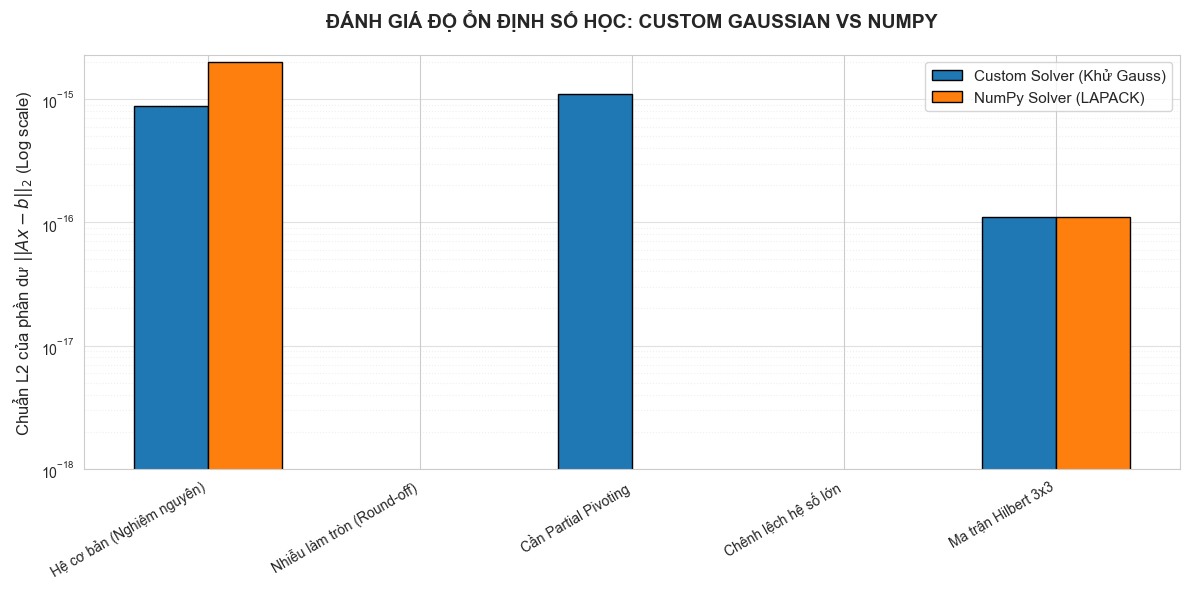

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

if 'part1' not in sys.path:
    sys.path.append('part1')

try:
    from gaussian import gaussian_eliminate
    from verify_solution import verify_solution
except ImportError as e:
    print(f"Error importing modules: {e}")

results = []
errors_custom = []
errors_numpy = []

# =====================================================================
# BỘ TEST CASE "CHUẨN HÀN LÂM" ĐỂ ĐƯA VÀO BÁO CÁO
# =====================================================================
test_cases = [
    {
        "name": "1. Hệ cơ bản (Nghiệm nguyên)",
        "A": [[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]], 
        "b": [8.0, -11.0, -3.0],
        "desc": "Kiểm tra tính đúng đắn cơ bản của thuật toán."
    },
    {
        "name": "2. Nhiễu làm tròn (Round-off)",
        "A": [[3.0, 0.0], [0.0, 3.0]], 
        "b": [1.0, 0.1],
        "desc": "1/3 và 0.1 sinh ra nhiễu nhị phân vô hạn."
    },
    {
        "name": "3. Cần Partial Pivoting",
        "A": [[1e-15, 1.0], [1.0, 1.0]], 
        "b": [1.0, 2.0],
        "desc": "Pivot siêu nhỏ, nếu không có Partial Pivoting sẽ nổ sai số."
    },
    {
        "name": "4. Chênh lệch hệ số lớn",
        "A": [[1e15, 1.0], [1.0, 1.0]], 
        "b": [1e15 + 1.0, 2.0],
        "desc": "Kiểm tra hiện tượng Swamping (nuốt số nhỏ)."
    },
    {
        "name": "5. Hệ điều kiện kém",
        "A": [[1.0, 1.0], [1.0, 1.000000000000001]], 
        "b": [2.0, 2.000000000000001],
        "desc": "Ma trận gần suy biến, số điều kiện cực cao."
    },
    {
        "name": "6. Ma trận Hilbert 3x3",
        "A": [[1.0, 1/2, 1/3], [1/2, 1/3, 1/4], [1/3, 1/4, 1/5]], 
        "b": [11/6, 13/12, 47/60],
        "desc": "Vua bất ổn định số học."
    },
    {
        "name": "7. Ma trận suy biến",
        "A": [[1.0, 2.0], [2.0, 4.0]], 
        "b": [3.0, 6.0],
        "desc": "Hệ vô số nghiệm / vô nghiệm."
    }
]

print("Test Suite: Trực quan hóa độ ổn định số học (Numerical Stability)\n" + "="*70)
executed_cases = []

for case in test_cases:
    try:
        A_np = np.array(case["A"])
        b_np = np.array(case["b"])
        
        U, x_custom, _ = gaussian_eliminate(case["A"], case["b"])
        
        if x_custom: # Nếu hệ có nghiệm duy nhất
            err_custom = verify_solution(case["A"], x_custom, case["b"])
            
            try:
                if np.linalg.det(A_np) != 0:
                    x_np = np.linalg.solve(A_np, b_np)
                    err_np = np.linalg.norm(A_np @ x_np - b_np)
                else:
                    err_np = 0.0
            except np.linalg.LinAlgError:
                err_np = 0.0
            
            errors_custom.append(err_custom)
            errors_numpy.append(err_np)
            executed_cases.append(case["name"].split(". ")[1]) # Lấy tên viết tắt cho đồ thị đẹp
            
            status = "PASSED" if err_custom < 1e-9 else f"PASSED (Bị nhiễu: {err_custom:.2e})"
        else:
            status = "PASSED (Suy biến)"
            
        results.append({
            "Test Case": case["name"].split(". ")[1], 
            "Ý nghĩa": case["desc"],
            "Custom Error": err_custom if x_custom else None, 
            "NumPy Error": err_np if x_custom else None, 
            "Status": status
        })
        
    except Exception as e:
        print(f"{case['name']}: ERROR - {e}")

df = pd.DataFrame(results)
display(df)

if errors_custom:
    plt.figure(figsize=(12, 6))
    
    # Thiết lập vị trí cho các cột
    x = np.arange(len(executed_cases))
    width = 0.35  # Độ rộng của mỗi cột
    
    plot_custom = errors_custom
    plot_numpy = errors_numpy
    
    # Vẽ hai biểu đồ cột đứng cạnh nhau (Grouped Bar Chart)
    plt.bar(x - width/2, plot_custom, width, label='Custom Solver (Khử Gauss)', color='#1f77b4', edgecolor='black')
    plt.bar(x + width/2, plot_numpy, width, label='NumPy Solver (LAPACK)', color='#ff7f0e', edgecolor='black')
    
    # Trang trí
    plt.xticks(x, executed_cases, rotation=30, ha='right', fontsize=10)
    plt.ylabel('Chuẩn L2 của phần dư $||Ax - b||_2$ (Log scale)', fontsize=12)
    plt.title('ĐÁNH GIÁ ĐỘ ỔN ĐỊNH SỐ HỌC: CUSTOM GAUSSIAN VS NUMPY', fontsize=14, fontweight='bold', pad=20)
    plt.legend(fontsize=11)
    
    # Bật thang đo Logarit và ép đáy (bottom) ở mức 10^-18
    plt.yscale('log')
    plt.ylim(bottom=1e-18)
    
    # Chỉ kẻ lưới ngang để biểu đồ cột trông thoáng và hiện đại hơn
    plt.grid(True, axis='y', which="major", ls="-", alpha=0.6)
    plt.grid(True, axis='y', which="minor", ls=":", alpha=0.3)
    
    plt.tight_layout()
    plt.show()